# GEDI Footprint Extraction Workflow

Extracts GEDI footrpints over a given area of interest and their corresponding Level 2A height metrics and L4A biomass metrics. Filters to high-quality returns, and exports point and footprint (25 m buffer) GeoJSON files and CSV files.

**Area of Interest Bounding box:** Set from a `.gdb` boundary file (interactive dialog) **or** entered manually below.

**This is notebook 1 of 2.** It pulls GEDI data, filters it, and clips it to the study area of interest. 
**`2_gedi_footprint_analysis_&_geolocation_error.ipynb`** can be used for the Monte Carlo geolocation error simulation, CHM comparisons, and plots. That notebook loads files saved here. 

---
## Setup
Set kernel to: base(Python 3.13.11)
Install required packages if you haven't already:

```bash
# in Google Colab:
#   !pip install earthaccess h5py numpy pandas geopandas shapely fiona -q
# in VS Code terminal:python -m pip install earthaccess h5py numpy pandas geopandas shapely fiona
#   
```

In [17]:
#------------ imports ----------------------------------------------------------
print("Importing libraries...")
import earthaccess
import h5py
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import datetime
import os
import tkinter as tk
from tkinter import filedialog, simpledialog
import fiona
from pyproj import CRS, Transformer



Importing libraries...


---
## Step 1: Set Output Folder and File Header

A dialog will open asking you to:
1. Select the folder where output files (CSV, GeoJSON) will be saved
2. Enter a short header used to name all output files (e.g. `bpines` → `bpines_gedi_shots.csv`)

In [18]:
data_folder = input("Enter output folder path: ").strip().strip('"')
file_header = input("Enter file name header (e.g. 'bpines'): ").strip().lower().replace(" ", "_")

csv_path            = os.path.join(data_folder, f'{file_header}_gedi_shots.csv')
geojson_path        = os.path.join(data_folder, f'{file_header}_gedi_shots.geojson')
buffer_geojson_path = os.path.join(data_folder, f'{file_header}_gedi_footprints.geojson')

print(f"\nOutput files will be:")
print(f"  {csv_path}")
print(f"  {geojson_path}")
print(f"  {buffer_geojson_path}")


Output files will be:
  C:\Users\davisk10\OneDrive - Cal Poly\Tree Biomass Estimation Research - Documents\CODE\GEDI_VERSION_3_OUPUTS\full_bart_v3_gedi_shots.csv
  C:\Users\davisk10\OneDrive - Cal Poly\Tree Biomass Estimation Research - Documents\CODE\GEDI_VERSION_3_OUPUTS\full_bart_v3_gedi_shots.geojson
  C:\Users\davisk10\OneDrive - Cal Poly\Tree Biomass Estimation Research - Documents\CODE\GEDI_VERSION_3_OUPUTS\full_bart_v3_gedi_footprints.geojson


---
## Step 2: Define Area of Interest Bounding Box

**Option A** — Load from a `.gdb` boundary file (recommended) or select a GeoJSON file: run the cell below.

**Option B** — Enter coordinates manually: skip to the manual cell further below.

### Option A: Load boundary from .gdb or GeoJSON

In [19]:
# Select the boundary file (.gdb folder OR a single-layer file like .geojson/.shp)
boundary_path = input("Paste the path to your boundary file (.gdb folder, .geojson, or .shp): ").strip().strip('"')
if not boundary_path:
    raise SystemExit("No boundary path entered. Exiting.")

if boundary_path.lower().endswith('.gdb'):
    # Geodatabase — may contain multiple layers, ask which one to use
    layers = fiona.listlayers(boundary_path)
    print("\nLayers found in geodatabase:")
    for i, layer in enumerate(layers):
        print(f"  {i + 1}: {layer}")

    layer_index = int(input(f"\nEnter the number of the layer to use as the clipping boundary (1-{len(layers)}): ").strip())
    if not layer_index:
        raise SystemExit("No layer selected. Exiting.")
    layer_name = layers[layer_index - 1]
    print(f"\nUsing layer: {layer_name}")

    boundary = gpd.read_file(boundary_path, layer=layer_name)
else:
    # Single-layer file (.geojson, .shp, etc.) — no layer selection needed
    boundary = gpd.read_file(boundary_path)
    print(f"\nUsing boundary file: {boundary_path}")

# Load the boundary layer and compute bounding box
boundary_wgs84 = boundary.to_crs("EPSG:4326")
minx, miny, maxx, maxy = boundary_wgs84.total_bounds
LON_MIN, LAT_MIN, LON_MAX, LAT_MAX = minx, miny, maxx, maxy

print(f"\nBounding box derived from boundary:")
print(f"LAT_MIN, LAT_MAX = {LAT_MIN:.6f}, {LAT_MAX:.6f}")
print(f"LON_MIN, LON_MAX = {LON_MIN:.6f}, {LON_MAX:.6f}")


Using boundary file: C:\Users\davisk10\OneDrive - Cal Poly\Tree Biomass Estimation Research - Documents\CODE\Bartleson_Ranch_Output_Files\bartleson_boundary.geojson

Bounding box derived from boundary:
LAT_MIN, LAT_MAX = 35.079525, 35.096023
LON_MIN, LON_MAX = -120.553011, -120.530919


### Option B: Insert coordinates manually

Only run this cell if you skipped Option A.

In [ ]:
# # -------- Insert coordinates for area of interest -----------------------------
# LAT_MIN, LAT_MAX = 35.309, 35.312
# LON_MIN, LON_MAX = -120.664, -120.657

# # Create a boundary polygon from the manual coordinates (needed for clipping in Step 9)
# from shapely.geometry import box
# boundary = gpd.GeoDataFrame(geometry=[box(LON_MIN, LAT_MIN, LON_MAX, LAT_MAX)], crs="EPSG:4326")

---
## Step 3: Login to NASA Earthdata

In [6]:
# ---------- Login to NASA Earthdata -------------------------------------------
# prompts for NASA Earthdata username and password
earthaccess.login()

---
## Step 4: Search for GEDI L2A (Height) Granules

In [20]:
# ---------- Search for GEDI granules over area of interest --------------------
print('Searching for GEDI granules...')
results = earthaccess.search_data(
    short_name='GEDI02_A',
    version='003',
    bounding_box=(LON_MIN, LAT_MIN, LON_MAX, LAT_MAX)
)
print(f'Found {len(results)} granules covering your Area of Interest.')

Searching for GEDI granules...
Found 32 granules covering your Area of Interest.


c:\Users\davisk10\miniconda3\Lib\site-packages\earthaccess\results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


---
## Step 4b: Search for GEDI L4A (Biomass) Granules

GEDI L4A provides footprint-level **aboveground biomass density (AGBD)** predictions generated from the same L2A waveforms. Each L4A shot carries the identical `shot_number` as its L2A counterpart. Searches the same bounding box as entered in Step 4.

In [21]:
# ---------- Search for GEDI L4A (biomass) granules over area of interest ------
# NOTE: L4A is hosted by ORNL DAAC (not LP DAAC like L2A), and its CMR collection
# version is '3' 
print('Searching for GEDI L4A (biomass) granules...')
results_biomass = earthaccess.search_data(
    doi='10.3334/ORNLDAAC/2508',
    bounding_box=(LON_MIN, LAT_MIN, LON_MAX, LAT_MAX)
)
print(f'Found {len(results_biomass)} L4A granules covering your area of interest')

# Fallback: if this still finds 0 granules (e.g. version string changes again),
# drop the version constraint and let CMR return whatever is current.
if len(results_biomass) == 0:
    print('No granules with version 3 -- retrying without a version constraint...')
    results_biomass = earthaccess.search_data(
        short_name='GEDI04_A',
        bounding_box=(LON_MIN, LAT_MIN, LON_MAX, LAT_MAX)
    )
    print(f'Found {len(results_biomass)} L4A granules covering your area of interest')

Searching for GEDI L4A (biomass) granules...


c:\Users\davisk10\miniconda3\Lib\site-packages\earthaccess\search.py:946: FutureWarning: As of version 1.0, `DataCollection.concept_id` will be accessed as an attribute; e.g. use `DataCollection.concept_id` **not** `DataCollection.concept_id()`
  concept_id = collection[0].concept_id()


Found 31 L4A granules covering your area of interest


---
## Step 5: Stream Granules and Extract Shots

Streams each granule directly without need for downloading. (~20 min depending on granule count)

In [22]:
# --- Stream each granule and extract shots (~20 min) --------------------------
all_shots = []
# waveform_store = {}   # NEEDS UPDATING FOR V3 VARIABLES 
                      # stores raw waveform arrays keyed by shot_number
                      # kept separate from the DataFrame because each shot has
                      # a variable number of waveform samples (~200–2000 values)

for granule in results:
    filename = granule['meta']['native-id']
    print(f'\nProcessing: {filename}')

    try:
        # Stream the file directly — no download needed
        files = earthaccess.open([granule])
        h5file = h5py.File(files[0], 'r')
        beams = [k for k in h5file.keys() if k.startswith('BEAM')]

        for beam in beams:
            try:
                lat = h5file[beam]['lat_lowestmode'][:]
                lon = h5file[beam]['lon_lowestmode'][:]

                # Filter to Area of Interest bounding box
                mask = (
                    (lat >= LAT_MIN) & (lat <= LAT_MAX) &
                    (lon >= LON_MIN) & (lon <= LON_MAX)
                )

                if mask.sum() == 0:
                    continue

                print(f'  {beam}: {mask.sum()} shots in Area of Interest')

                rh = h5file[beam]['rh'][mask]

                # Date from filename
                try:
                    year = int(filename[9:13])
                    doy  = int(filename[13:16])
                    date = datetime.datetime(year, 1, 1) + datetime.timedelta(doy - 1)
                    date_str = date.strftime('%Y-%m-%d')
                except:
                    date_str = 'unknown'

                shot_data = {
                    'filename':     filename,
                    'beam':         beam,
                    'date':         date_str,
                    'lat':          lat[mask],
                    'lon':          lon[mask],
                    'rh25':         rh[:, 25],
                    'rh50':         rh[:, 50],
                    'rh75':         rh[:, 75],
                    'rh85':         rh[:, 85],
                    'rh95':         rh[:, 95],  
                    'rh96':         rh[:, 96],
                    'rh97':         rh[:, 97],
                    'rh98':         rh[:, 98], # relative height at 98th percentile (top of forest canopy height in m)
                    'rh99':         rh[:, 99],
                    'rh100':        rh[:, 100],
                    'sensitivity':  h5file[beam]['sensitivity'][mask], # how well detected ground return through the canopy, ranges from 0 to 1
                                                                        #0.9 - 1.0 → excellent — laser punched through canopy cleanly and found ground
                    'quality_flag2': h5file[beam]['l2a_quality_flag_rel2'][mask], # quality flag from version 2 (https://lpdaac.usgs.gov/documents/2442/GEDI02_User_Guide_V3.pdf)
                    'quality_flag3': h5file[beam]['l2a_quality_flag_rel3'][mask], # quality flag from version 3 
                    'degrade_flag':  h5file[beam]['degrade_flag'][mask],
                    'shot_number':   h5file[beam]['shot_number'][mask].astype(str),
                    'lat_error':     h5file[beam]['latitude_bin0_error'][mask],
                    'lon_error':     h5file[beam]['longitude_bin0_error'][mask],
                    'elev_error':    h5file[beam]['elevation_bin0_error'][mask],
                }

                all_shots.append(pd.DataFrame(shot_data))
                # # ── Extract raw waveforms for shots in bounding box -> NEEDS UPDATING WITH V3 VARIABLES ───────────
                # # rxwaveform is one long 1D array for the entire beam —
                # # rx_sample_start_index and rx_sample_count tell us where
                # # each individual shot's waveform starts and how long it is
                # rx_waveform   = h5file[beam]['rxwaveform'][:]
                # start_indices = h5file[beam]['rx_sample_start_index'][mask]
                # sample_counts = h5file[beam]['rx_sample_count'][mask]
                # shot_numbers  = h5file[beam]['shot_number'][mask]   # ← add this line

                # for i in range(mask.sum()):
                #     sn    = str(shot_numbers[i])
                #     start = start_indices[i]
                #     count = sample_counts[i]
                #     # slice out just this shot's waveform from the full beam array
                #     waveform_store[sn] = rx_waveform[start : start + count]


            except KeyError as e:
                print(f'  Skipping {beam} — missing field: {e}')
                continue

        h5file.close()

    except Exception as e:
        print(f'  Error: {e}')
        continue


Processing: GEDI02_A_2019170220937_O02936_03_T02118_02_004_02_V003


c:\Users\davisk10\miniconda3\Lib\site-packages\earthaccess\store.py:523: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

...

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]


Processing: GEDI02_A_2025177154916_O37032_03_T03541_02_004_02_V003


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

---
## Step 5b: Stream L4A Granules and Extract Biomass

Same streaming approach as Step 5, but for the GEDI04_A biomass fields instead of L2A height metrics. Key fields:

- **`agbd`**: predicted aboveground biomass density (Mg/ha)
- **`agbd_se`**: Standard Error of the AGBD prediction (Mg/ha)
- **`l4_quality_flag`**: if = 1, the shot is a reliable sample of the population the biomass model was trained on (this is separate from, and in addition to, the L2A `quality_flag`. Can filter on the l4_quality_flag further down the line for a high-confidence biomass subset)
- **`algorithm_run_flag`**: if = 1, the L4A algorithm actually produced a prediction for this shot (0 = no estimate, e.g. over water)

Because `shot_number` matches its L2A counterpart exactly, the two datasets can be merged in Step 6b.

In [23]:
# --- Stream each L4A granule and extract biomass shots ------------------------
all_biomass = []

for granule in results_biomass:
    filename = granule['meta']['native-id']
    print(f'\nProcessing: {filename}')

    try:
        # Stream the file directly — no download needed
        files = earthaccess.open([granule])
        h5file = h5py.File(files[0], 'r')
        beams = [k for k in h5file.keys() if k.startswith('BEAM')]

        for beam in beams:
            try:
                lat = h5file[beam]['lat_lowestmode'][:]
                lon = h5file[beam]['lon_lowestmode'][:]

                # Filter to the same bounding box used for L2A
                mask = (
                    (lat >= LAT_MIN) & (lat <= LAT_MAX) &
                    (lon >= LON_MIN) & (lon <= LON_MAX)
                )

                if mask.sum() == 0:
                    continue

                print(f'  {beam}: {mask.sum()} shots in area of interest')

                biomass_data = {
                    'shot_number':       h5file[beam]['shot_number'][mask].astype(str),
                    'agbd':              h5file[beam]['agbd'][mask],              # aboveground biomass density (Mg/ha)
                    'agbd_se':           h5file[beam]['agbd_se'][mask],           # standard error of agbd (Mg/ha)
                    'l4_quality_flag':   h5file[beam]['l4a_quality_flag_rel3'][mask],   # 1 = reliable AGBD sample
                    'algorithm_run_flag':h5file[beam]['l2_algrunflag'][mask],# 1 = L4A model produced a prediction
                    'sensitivity_l4a':   h5file[beam]['sensitivity'][mask],
                    'degrade_flag_l4a':  h5file[beam]['degrade_flag'][mask],
                }

                all_biomass.append(pd.DataFrame(biomass_data))

            except KeyError as e:
                print(f'  Skipping {beam} — missing field: {e}')
                continue

        h5file.close()

    except Exception as e:
        print(f'  Error: {e}')
        continue

if len(all_biomass) == 0:
    biomass_df = pd.DataFrame(columns=['shot_number', 'agbd', 'agbd_se', 'l4_quality_flag',
                                        'algorithm_run_flag', 'sensitivity_l4a', 'degrade_flag_l4a'])
    print('\nNo L4A biomass shots found in area of interest')
else:
    biomass_df = pd.concat(all_biomass, ignore_index=True)
    biomass_df['shot_number'] = biomass_df['shot_number'].astype(str)
    print(f'\nTotal L4A biomass shots found: {len(biomass_df)}')


Processing: GEDI04_A_2019170220937_O02936_03_T02118_02_004_01_V003


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]


Processing: GEDI04_A_2019212222100_O03588_02_T04378_02_004_01_V003


...


Processing: GEDI04_A_2025177154916_O37032_03_T03541_02_004_02_V003


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]


Total L4A biomass shots found: 1133


---
## Step 6: Filter to High-Quality L2A Shots and Save Outputs

In [24]:
# ------------- Combine all shots ----------------------------------------------
if len(all_shots) == 0:
    print('\nNo shots found in Area of Interest.')
else:
    combined = pd.concat(all_shots, ignore_index=True)
    print(f'\nTotal shots found: {len(combined)}')

    # Filter to high quality shots only
    quality = combined[
        (combined['quality_flag3'] == 1) &
        (combined['degrade_flag'] == 0)
    ].copy()
    print(f'High quality shots: {len(quality)}')

    # Combined horizontal geolocation uncertainty per footprint
    quality['horizontal_geoloc_error_m'] = np.sqrt(
        quality['lat_error']**2 + quality['lon_error']**2
    )

    print(quality[['date', 'beam', 'lat', 'lon', 'rh98', 'sensitivity']].to_string())

    # Ensure shot_number stays as string (ArcGIS Pro compatibility)
    quality['shot_number'] = quality['shot_number'].astype(str)

    # Save CSV
    quality.to_csv(csv_path, index=False)
    print(f'\nCSV saved: {csv_path}')


Total shots found: 1219
High quality shots: 568
            date      beam        lat         lon       rh98  sensitivity
4     2019-09-20  BEAM0000  35.095902 -120.544108   3.400000     0.951063
5     2019-09-20  BEAM0000  35.095551 -120.543649   3.100000     0.938111
6     2019-09-20  BEAM0000  35.095201 -120.543191   3.250000     0.957686
7     2019-09-20  BEAM0000  35.094851 -120.542733   3.180000     0.957387
8     2019-09-20  BEAM0000  35.094500 -120.542275   3.250000     0.952875
9     2019-09-20  BEAM0000  35.094150 -120.541816   3.590000     0.952596
10    2019-09-20  BEAM0000  35.093798 -120.541355   3.970000     0.943250
11    2019-09-20  BEAM0000  35.093447 -120.540895   3.820000     0.939770
12    2019-09-20  BEAM0000  35.093097 -120.540437   4.790000     0.924245
13    2019-09-20  BEAM0000  35.092747 -120.539980   2.500000     0.935446
14    2019-09-20  BEAM0000  35.092395 -120.539521   3.630000     0.940222
15    2019-09-20  BEAM0000  35.092044 -120.539061   3.850000   

*Note: the extraction/filtering work ends at Step 9 below. All further analysis (Monte Carlo simulation, CHM comparisons, plots) lives in the companion notebook `gedi_footprint_2_analysis.ipynb`, which loads the files saved here instead of re-running the GEDI search.*

---
## Step 6b: Merge L2A/L4A Quality Data into 2 Output Combinations

Joins L4A biomass fields onto `quality` via `shot_number`.

- **`quality`**: L2A-quality shots from Step 6 joined with all L4A biomass shots, regardless of quality. Shots with no
  L4A estimate keep `NaN` biomass columns rather than being dropped.
- **`both_quality`**: L2A and L4A quality shots only by further filtering to shots where `l4_quality_flag == 1` and
  `algorithm_run_flag == 1`.

Each is saved as its own CSV + point GeoJSON (`EPSG:4326`), so either loads straight
into QGIS as a point layer.

In [25]:
# ------------- Merge L4A biomass into the quality shot table = L2A QUALITY, ALL L4A ------------------
quality = quality.merge(biomass_df, on='shot_number', how='left')

matched = quality['agbd'].notna().sum()
print(f'L2A shots with a matching L4A biomass estimate: {matched} / {len(quality)}')
print(quality[['date', 'beam', 'lat', 'lon', 'rh98', 'agbd', 'agbd_se', 'l4_quality_flag']].to_string())

quality.to_csv(csv_path, index=False)
print(f'\nCSV re-saved with biomass columns: {csv_path}')

# ---- Both quality: L2A high-quality AND L4A high-confidence ------------------
both_quality = quality[
    (quality['l4_quality_flag'] == 1) &
    (quality['algorithm_run_flag'] == 1)
]
print(f'\nShots with BOTH L2A and L4A quality: {len(both_quality)}')
print(both_quality[['date', 'beam', 'lat', 'lon', 'rh98', 'quality_flag3', 'degrade_flag',
                     'agbd', 'agbd_se', 'l4_quality_flag']].to_string())

# Geolocation error for the final quality-deemed footprints
print('\nHorizontal geolocation error (m) for both_quality footprints:')
print(both_quality['horizontal_geoloc_error_m'].describe())

# ------------- Save outputs as CSV + point GeoJSON -----------------------------
def save_variant(df, tag):
    csv_out     = os.path.join(data_folder, f'{file_header}_gedi_shots_{tag}.csv')
    geojson_out = os.path.join(data_folder, f'{file_header}_gedi_shots_{tag}.geojson')

    df.to_csv(csv_out, index=False)

    geometry = [Point(lon, lat) for lon, lat in zip(df['lon'], df['lat'])]
    gdf = gpd.GeoDataFrame(df, geometry=geometry, crs='EPSG:4326')
    gdf.to_file(geojson_out, driver='GeoJSON')

    print(f'  {tag}: {len(df)} shots -> {csv_out}')
    print(f'  {tag}: {len(df)} shots -> {geojson_out}')

save_variant(both_quality, 'both_quality')

L2A shots with a matching L4A biomass estimate: 568 / 568
           date      beam        lat         lon       rh98        agbd   agbd_se  l4_quality_flag
0    2019-09-20  BEAM0000  35.095902 -120.544108   3.400000    1.607710  4.798247                1
1    2019-09-20  BEAM0000  35.095551 -120.543649   3.100000    1.205236  4.799189                1
2    2019-09-20  BEAM0000  35.095201 -120.543191   3.250000    1.399310  4.798711                1
3    2019-09-20  BEAM0000  35.094851 -120.542733   3.180000    1.306958  4.798933                1
4    2019-09-20  BEAM0000  35.094500 -120.542275   3.250000    1.399310  4.798711                1
5    2019-09-20  BEAM0000  35.094150 -120.541816   3.590000    1.892197  4.797674                1
6    2019-09-20  BEAM0000  35.093798 -120.541355   3.970000    2.529721  4.796581                1
7    2019-09-20  BEAM0000  35.093447 -120.540895   3.820000    2.267170  4.797004                1
8    2019-09-20  BEAM0000  35.093097 -120.540437   

---
## Step 7: Export Center Coordinate Points of Footprints to GeoJSON

In [26]:
# ── Step 7: Build point GeoDataFrame ──────────────────────────────────────────
if len(quality) == 0:
    print('No quality shots to export. Exiting.')
else:
    geometry_pts = [Point(lon, lat) for lon, lat in zip(quality['lon'], quality['lat'])]
    gdf_points = gpd.GeoDataFrame(quality, geometry=geometry_pts, crs='EPSG:4326')

    # Save point GeoJSON
    gdf_points.to_file(geojson_path, driver='GeoJSON')
    print(f'Point GeoJSON saved: {geojson_path}')

Point GeoJSON saved: C:\Users\davisk10\OneDrive - Cal Poly\Tree Biomass Estimation Research - Documents\CODE\GEDI_VERSION_3_OUPUTS\full_bart_v3_gedi_shots.geojson


---
## Step 8: Create 25 m Footprint Buffers and Export

**WHY WE REPROJECT:**  
GEDI points are stored in WGS84 (EPSG:4326), where coordinates are in degrees. Buffering in degrees does NOT give you metres — 0.0001° of longitude is ~9 m near the equator but changes with latitude.

Solution: reproject to a CRS measured in metres, buffer by exactly 12.5 m (radius), then reproject back to WGS84.

UTM Zone 10N (EPSG:32610) covers central California and is appropriate for this study area. Adjust the EPSG code if your ROI is in a different UTM zone.

**WHAT THE BUFFER DOES:**  
Each GEDI shot records a single lat/lon centre point, but the real laser footprint illuminates a ~25 m diameter circle on the ground. `buffer(12.5)` expands each point into a circle with radius 12.5 m, giving a 25 m diameter polygon that matches the physical footprint. When you later extract biomass, canopy height, or image pixel values WITHIN these polygons, you are sampling the same area the lidar saw.

In [27]:
# ── Step 8: Create 25 m footprint buffers ─────────────────────────────────────
UTM_CRS = 'EPSG:32610'   # UTM Zone 10N — change if your site is elsewhere

gdf_utm = gdf_points.to_crs(UTM_CRS)
gdf_utm['geometry'] = gdf_utm.geometry.buffer(12.5)    # 12.5 m radius → 25 m diameter
gdf_footprints = gdf_utm.to_crs('EPSG:4326')           # reproject back to WGS84

gdf_footprints.to_file(buffer_geojson_path, driver='GeoJSON')
print(f'Footprint GeoJSON saved (25 m buffers): {buffer_geojson_path}')

print('\nDone! Load the GeoJSON files into QGIS or ArcGIS Pro.')
print('Outputs:')
print(f'  Points     → {geojson_path}')
print(f'  Footprints → {buffer_geojson_path}')
print(f'  CSV        → {csv_path}')

Footprint GeoJSON saved (25 m buffers): C:\Users\davisk10\OneDrive - Cal Poly\Tree Biomass Estimation Research - Documents\CODE\GEDI_VERSION_3_OUPUTS\full_bart_v3_gedi_footprints.geojson

Done! Load the GeoJSON files into QGIS or ArcGIS Pro.
Outputs:
  Points     → C:\Users\davisk10\OneDrive - Cal Poly\Tree Biomass Estimation Research - Documents\CODE\GEDI_VERSION_3_OUPUTS\full_bart_v3_gedi_shots.geojson
  Footprints → C:\Users\davisk10\OneDrive - Cal Poly\Tree Biomass Estimation Research - Documents\CODE\GEDI_VERSION_3_OUPUTS\full_bart_v3_gedi_footprints.geojson
  CSV        → C:\Users\davisk10\OneDrive - Cal Poly\Tree Biomass Estimation Research - Documents\CODE\GEDI_VERSION_3_OUPUTS\full_bart_v3_gedi_shots.csv


---
## Diagnostic: Why Were Shots Rejected?

Re-streams all granules without quality filtering and prints a breakdown of rejection reasons. Run this if you want to understand why shots were excluded.

In [ ]:
# # ------ Diagnostic: why were shots rejected? ----------------------------------

# all_shots_unfiltered = []

# for granule in results:
#     filename = granule['meta']['native-id']

#     try:
#         files = earthaccess.open([granule])
#         h5file = h5py.File(files[0], 'r')
#         beams = [k for k in h5file.keys() if k.startswith('BEAM')]

#         for beam in beams:
#             try:
#                 lat = h5file[beam]['lat_lowestmode'][:]
#                 lon = h5file[beam]['lon_lowestmode'][:]

#                 mask = (
#                     (lat >= LAT_MIN) & (lat <= LAT_MAX) &
#                     (lon >= LON_MIN) & (lon <= LON_MAX)
#                 )

#                 if mask.sum() == 0:
#                     continue

#                 quality_flag = h5file[beam]['quality_flag'][mask]
#                 degrade_flag = h5file[beam]['degrade_flag'][mask]
#                 sensitivity  = h5file[beam]['sensitivity'][mask]

#                 # Date from filename
#                 try:
#                     year = int(filename[9:13])
#                     doy  = int(filename[13:16])
#                     date = datetime.datetime(year, 1, 1) + datetime.timedelta(doy - 1)
#                     date_str = date.strftime('%Y-%m-%d')
#                 except:
#                     date_str = 'unknown'

#                 for i in range(mask.sum()):
#                     all_shots_unfiltered.append({
#                         'filename':     filename,
#                         'beam':         beam,
#                         'date':         date_str,
#                         'lat':          lat[mask][i],
#                         'lon':          lon[mask][i],
#                         'quality_flag': quality_flag[i],
#                         'degrade_flag': degrade_flag[i],
#                         'sensitivity':  sensitivity[i],
#                         'rejected':     quality_flag[i] != 1 or degrade_flag[i] != 0
#                     })

#             except KeyError as e:
#                 continue

#         h5file.close()

#     except Exception as e:
#         print(f'Error: {e}')
#         continue

# # ── Summary ───────────────────────────────────────────────────────────────────
# df_all = pd.DataFrame(all_shots_unfiltered)

# print(f'Total shots in bounding box: {len(df_all)}')
# print(f'Accepted (quality=1, degrade=0): {len(df_all[~df_all["rejected"]])}')
# print(f'Rejected: {len(df_all[df_all["rejected"]])}')
# print()
# print('Rejection breakdown:')
# print(f'  quality_flag = 0: {len(df_all[df_all["quality_flag"] == 0])}')
# print(f'  degrade_flag != 0: {len(df_all[df_all["degrade_flag"] != 0])}')
# print()
# print('Rejected shots by date and beam:')
# rejected = df_all[df_all['rejected']]
# print(rejected[['date', 'beam', 'lat', 'lon', 'quality_flag', 'degrade_flag', 'sensitivity']].to_string())

---
## Step 9: Clip GEDI Footprints to Previously Entered Study Area Bounday 

In [28]:
## Step 9: Clip Footprints to Study Area Boundary

# Reproject boundary to WGS84 to match footprints
boundary_wgs84 = boundary.to_crs("EPSG:4326")
boundary_union = boundary_wgs84.union_all()  # single geometry for comparison

# Keep only footprints completely within the boundary
gdf_footprints_clipped = gdf_footprints[gdf_footprints.geometry.within(boundary_union)].copy()

# Match points to surviving footprints using shot_number
gdf_points_clipped = gdf_points[gdf_points['shot_number'].isin(gdf_footprints_clipped['shot_number'])].copy()

print(f"Footprints before filtering:      {len(gdf_footprints)}")
print(f"Footprints fully within boundary: {len(gdf_footprints_clipped)}")
print(f"Points matched to footprints:     {len(gdf_points_clipped)}")

# Save outputs
clipped_footprints_path = os.path.join(data_folder, f'{file_header}_gedi_footprints_clipped.geojson')
clipped_points_path     = os.path.join(data_folder, f'{file_header}_gedi_shots_clipped.geojson')

gdf_footprints_clipped.to_file(clipped_footprints_path, driver='GeoJSON')
gdf_points_clipped.to_file(clipped_points_path, driver='GeoJSON')

print(f"\nClipped footprints saved: {clipped_footprints_path}")
print(f"Clipped points saved:     {clipped_points_path}")

print(f"Footprints before filtering:      {len(gdf_footprints)}")
print(f"Footprints fully within boundary: {len(gdf_footprints_clipped)}")
print(f"Points matched to footprints:     {len(gdf_points_clipped)}")

# Geolocation error for each footprint within the study area boundary
print('\nGeolocation error per clipped footprint:')
print(gdf_points_clipped[['shot_number', 'horizontal_geoloc_error_m']].to_string(index=False))

Footprints before filtering:      568
Footprints fully within boundary: 239
Points matched to footprints:     239

Clipped footprints saved: C:\Users\davisk10\OneDrive - Cal Poly\Tree Biomass Estimation Research - Documents\CODE\GEDI_VERSION_3_OUPUTS\full_bart_v3_gedi_footprints_clipped.geojson
Clipped points saved:     C:\Users\davisk10\OneDrive - Cal Poly\Tree Biomass Estimation Research - Documents\CODE\GEDI_VERSION_3_OUPUTS\full_bart_v3_gedi_shots_clipped.geojson
Footprints before filtering:      568
Footprints fully within boundary: 239
Points matched to footprints:     239

Geolocation error per clipped footprint:
       shot_number  horizontal_geoloc_error_m
 43710100300249202                   0.000063
 43710100300249203                   0.000063
 43710100300249204                   0.000063
 43710100300249205                   0.000063
 43710100300249206                   0.000063
 43710100300249207                   0.000063
 43710100300249208                   0.000063
 437

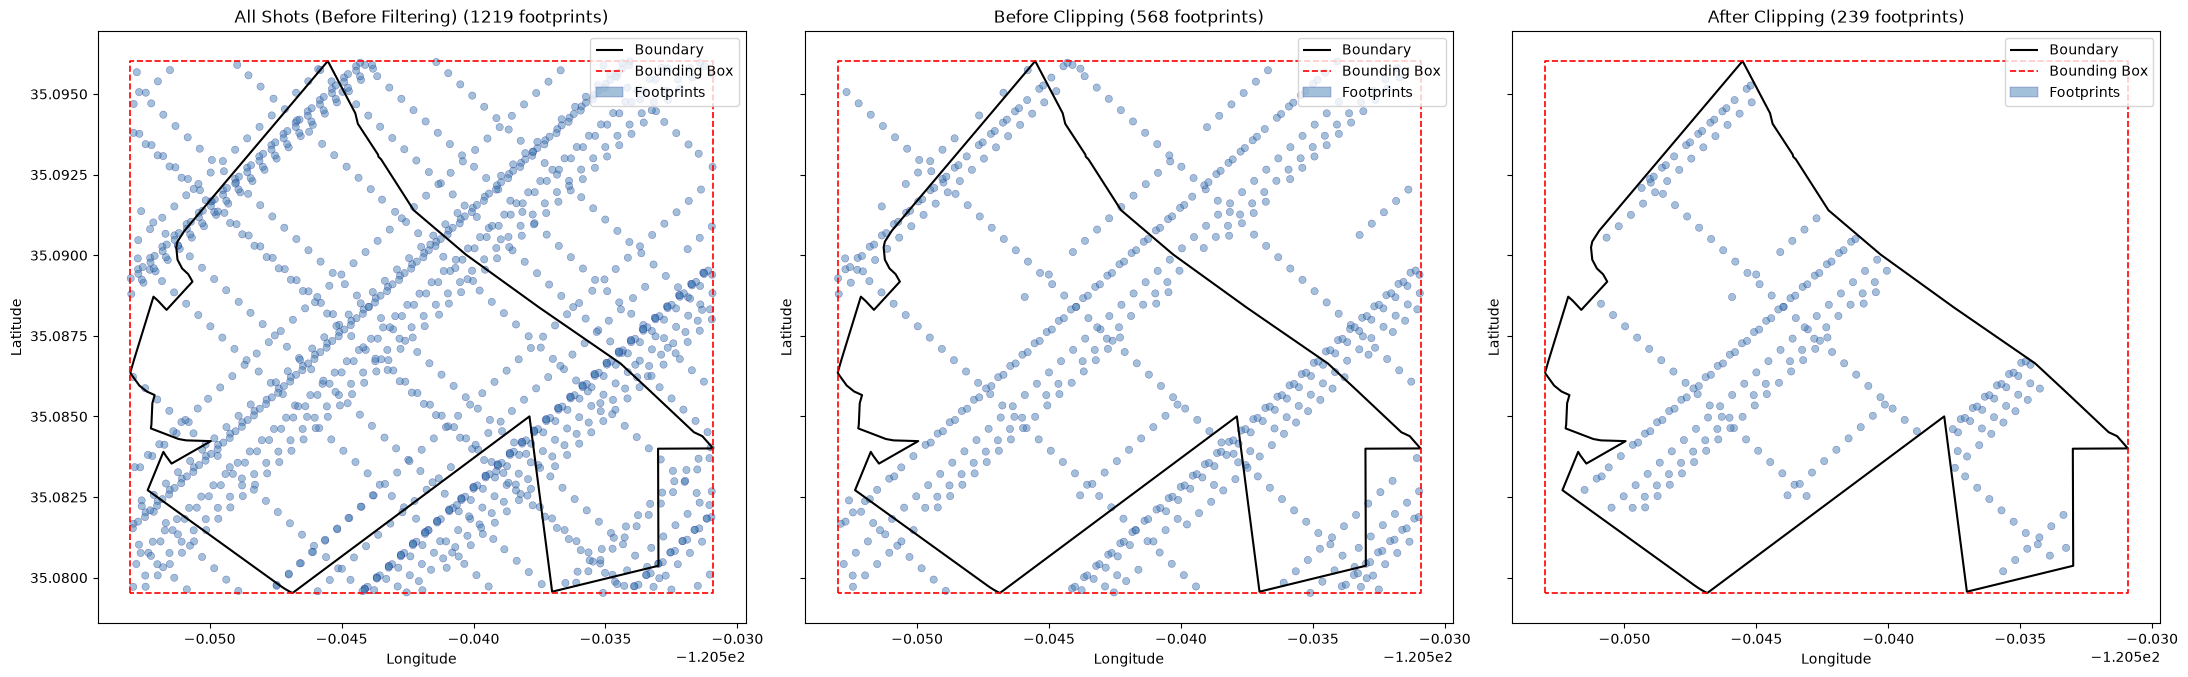

In [30]:
#VISUALIZATION TOOL:
# ── Visualize: All Shots (Unfiltered), Buffered Footprints Pre/Post Clip ──────
import matplotlib.pyplot as plt
from shapely.geometry import box, Point

def plot_boundary_and_footprints(boundary_gdf, combined_df, footprints_before, footprints_after,
                                  lon_min, lat_min, lon_max, lat_max, utm_crs='EPSG:32610'):
    """Plot the boundary, its bounding box, and buffered GEDI footprints:
    all shots before any quality filtering, before clipping, and after clipping."""
    bbox_geom = gpd.GeoDataFrame(
        geometry=[box(lon_min, lat_min, lon_max, lat_max)], crs="EPSG:4326"
    )
    boundary_wgs84 = boundary_gdf.to_crs("EPSG:4326")

    # Build buffered footprints from the raw, unfiltered shot table
    geometry = [Point(lon, lat) for lon, lat in zip(combined_df['lon'], combined_df['lat'])]
    gdf_all_shots = gpd.GeoDataFrame(combined_df, geometry=geometry, crs='EPSG:4326')
    gdf_all_shots_utm = gdf_all_shots.to_crs(utm_crs)
    gdf_all_shots_utm['geometry'] = gdf_all_shots_utm.geometry.buffer(12.5)
    footprints_unfiltered = gdf_all_shots_utm.to_crs('EPSG:4326')

    fig, axes = plt.subplots(1, 3, figsize=(22, 8), sharex=True, sharey=True)

    titles = ['All Shots (Before Filtering)', 'Before Clipping', 'After Clipping']
    footprint_sets = [footprints_unfiltered, footprints_before, footprints_after]

    for ax, title, footprints in zip(axes, titles, footprint_sets):
        boundary_wgs84.boundary.plot(ax=ax, color='black', linewidth=1.5, label='Boundary')
        bbox_geom.boundary.plot(ax=ax, color='red', linewidth=1.2, linestyle='--', label='Bounding Box')
        footprints.plot(ax=ax, color='steelblue', alpha=0.5, edgecolor='navy', linewidth=0.3, label='Footprints')

        ax.set_title(f'{title} ({len(footprints)} footprints)')
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        ax.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

plot_boundary_and_footprints(
    boundary, combined, gdf_footprints, gdf_footprints_clipped,
    LON_MIN, LAT_MIN, LON_MAX, LAT_MAX
)

---
## Done — Outputs for the Analysis Notebook

This notebook's job ends here. The cell below saves one more file — a flat CSV version of the clipped points (handy for opening directly in Excel) — and prints out every file that was produced.

**To continue the analysis (Monte Carlo simulation, CHM comparisons, plots, etc.), open `gedi_footprint_2_analysis.ipynb`.** It does *not* need this notebook to still be running — its first code cell opens a file-picker dialog so you can select the outputs saved below, any time, in a fresh kernel.

In [16]:
# ── Save a flat CSV of the clipped points (no geometry) for quick viewing ─────
clipped_csv_path = os.path.join(data_folder, f'{file_header}_gedi_shots_clipped.csv')
gdf_points_clipped.drop(columns='geometry', errors='ignore').to_csv(clipped_csv_path, index=False)

print('All outputs saved to:', data_folder)
print(f'  All quality shots (unclipped, height + biomass) : {csv_path}')
print(f'  All quality points (GeoJSON)                    : {geojson_path}')
print(f'  All footprints (GeoJSON)                        : {buffer_geojson_path}')
print(f'  Clipped points (GeoJSON)                        : {clipped_points_path}')
print(f'  Clipped footprints (GeoJSON)                    : {clipped_footprints_path}')
print(f'  Clipped points (flat CSV, height + biomass)     : {clipped_csv_path}')
print()
print('agbd = aboveground biomass density (Mg/ha); rh98 = canopy height (m).')
print('Open gedi_footprint_2_analysis.ipynb to continue — it will ask you')
print('to select the clipped points GeoJSON file above, and will auto-find')
print('the matching clipped footprints file in the same folder.')

All outputs saved to: C:\Users\davisk10\OneDrive - Cal Poly\Tree Biomass Estimation Research - Documents\CODE\GEDI_VERSION_3_OUPUTS
  All quality shots (unclipped, height + biomass) : C:\Users\davisk10\OneDrive - Cal Poly\Tree Biomass Estimation Research - Documents\CODE\GEDI_VERSION_3_OUPUTS\bart_v3_gedi_shots.csv
  All quality points (GeoJSON)                    : C:\Users\davisk10\OneDrive - Cal Poly\Tree Biomass Estimation Research - Documents\CODE\GEDI_VERSION_3_OUPUTS\bart_v3_gedi_shots.geojson
  All footprints (GeoJSON)                        : C:\Users\davisk10\OneDrive - Cal Poly\Tree Biomass Estimation Research - Documents\CODE\GEDI_VERSION_3_OUPUTS\bart_v3_gedi_footprints.geojson
  Clipped points (GeoJSON)                        : C:\Users\davisk10\OneDrive - Cal Poly\Tree Biomass Estimation Research - Documents\CODE\GEDI_VERSION_3_OUPUTS\bart_v3_gedi_shots_clipped.geojson
  Clipped footprints (GeoJSON)                    : C:\Users\davisk10\OneDrive - Cal Poly\Tree Biomass 

## Code for pulling boundary GeoJSON files from ArcGIS Online

In [ ]:
from arcgis.gis import GIS

gis = GIS("https://calpoly.maps.arcgis.com", client_id="arcgisPro")

In [ ]:
#in ArcGIS online, go to the content page of the feature layer desired to be downloaded onto local machine. 
# in the URL address of that content page, copy the item ID (the long string of letters and numbers after "id=") and paste it below
# do not include #overview
# item = gis.content.get("paste the item id here")
item = gis.content.get("d5d83b32da2f4fc3a974719608a806b4")
flayer = item.layers[0]

# ensure the output spatial reference is WGS84 (EPSG:4326)
fs = flayer.query(where="1=1", out_fields="*", out_sr=4326)
sdf = fs.sdf

# Drop any rows with missing geometry before converting
sdf = sdf[sdf['SHAPE'].notna()].copy()

# Convert each Esri geometry to a shapely geometry, then build a GeoDataFrame
import geopandas as gpd

sdf['geometry'] = sdf['SHAPE'].apply(lambda g: g.as_shapely)
gdf_boundary = gpd.GeoDataFrame(sdf.drop(columns='SHAPE'), geometry='geometry', crs='EPSG:4326')

# paste in the name of the output file desired to be saved on local machine.
# file gets saved to the same folder as this notebook, unless you specify a different path in the filename.
# ex. with open ("name_output_file.geojson", "w") as f:
# or  with open ("C:\\Users\\username\\Documents\\name_output_file.geojson", "w") as f: 
save_path = "C:\\Users\\davisk10\\OneDrive - Cal Poly\\Tree Biomass Estimation Research - Documents\\CODE\\Bartleson_Ranch_Output_Files\\bartleson_crops_boundaries.geojson"
gdf_boundary.to_file(save_path, driver='GeoJSON')

print(f"Saved {len(gdf_boundary)} boundary feature(s) to {save_path}")